<div style="display:none">
$$
\newcommand{\rvar}[1]{\mathrm{#1}}
\newcommand{\rvec}[1]{\mathbf{#1}}
\newcommand{\vec}[1]{\pmb{#1}}
\newcommand{\tens}[1]{\pmb{\mathsf{#1}}}
\newcommand{\tensel}[1]{\mathsf{#1}}
\newcommand{\st}[1]{\mathcal{#1}}
\newcommand{\diag}[1]{\mathrm{diag}(\vec{#1})}
$$
</div>

In [3]:
# Setup for Google Colab
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('dl_course'):
        !git clone -q --depth 1 https://github.com/konstantin-schekotihin/dl_course.git
    %cd -q /content/dl_course/02_ML
    !pip install -q torch-geometric wandb

# some initialization stuff
%run ../init.py
%matplotlib inline

<IPython.core.display.Latex object>

# Bayesian classifiers

## Two roles for Bayesian methods

- Provides practical learning algorithms:
    + Naive Bayes
    + Bayesian belief networks
    + Linear Discriminant Analysis
- Combine prior knowledge (prior probabilities) with observed data
    + Requires prior probabilities
- Provides useful conceptual framework
    + Provides "gold standard" for evaluating other learning algorithms

## Bayes theorem

- Given a data set $\vec{D}$ and a set of hypotheses $\st{H}=\{h_1, \dots, h_n\}$ - outcomes of a discrete random variable $\rvar{h}$
- The *posterior probability* of a hypothesis $\rvar{h} = h_j$ can be determined as:

$$ P(\rvar{h}=h_j\mid\vec{D}) = \frac{P(\vec{D}\mid\rvar{h}=h_j) P(\rvar{h}=h_j)}{P(\vec{D})} = \frac{P(\vec{D}\mid\rvar{h}=h_j) P(\rvar{h}=h_j)}{\sum_{\rvar{h}_i\in \st{H}}P(\vec{D}\mid\rvar{h}=h_i)P(\rvar{h}=h_i)}$$

- $P(\rvar{h})$ = prior probability of hypothesis $\rvar{h}$ - *prior*
- $P(\vec{D}\mid\rvar{h})$ = probability of $\vec{D}$ given $\rvar{h}$ - *likelihood*
- $P(\vec{D})$ = prior probability of training data $\vec{D}$ - *marginalization*, *evidence*, or *predictor prior*
- $P(\rvar{h}\mid\vec{D})$ = probability of $\rvar{h}$ given $\vec{D}$ - *posterior*

$$\mathit{posterior} = \frac{\mathit{likelihood}\times\mathit{prior}}{\mathit{evidence}}$$

## Problem: Bayes theorem


<div class="mydef">    
<b> Does a patient have COVID-19 or not?</b>

A patient takes a PCR test and the result comes back positive. The test
returns a correct positive result in only $98\%$ of the cases in which the
disease is actually present, and a correct negative result in only $97\%$ of
the cases in which the disease is not present.  Furthermore, $.008$ of the
entire Austria population are assumed to have COVID-19, i.e., out of 8'933'346 persons living in Austria 71'466 persons are ill  .
</div>

- Let $\rvar{covid}$ and $\rvar{test}$ be two Boolean random variables
- $\rvar{covid}=\mathit{True}$ and $\rvar{test} = \mathit{True}$ is denoted as $\rvar{covid}$ and $\rvar{+}$ for simplicity


<p class="fragment step-fade-in-then-out">
\begin{align*}
& P(\rvar{covid}) =   & & P(\neg \rvar{covid}) =  \\
& P(\rvar{+} \mid \rvar{covid}) =  & &P(\rvar{-} \mid \rvar{covid}) =   \\
& P(\rvar{+} \mid \neg \rvar{covid}) =   & & P(\rvar{-} \mid \neg \rvar{covid}) =  
\end{align*}
</p>
<p class="fragment step-fade-in-then-out">
\begin{align*}
& P(\rvar{covid}) =  0.008 & & P(\neg \rvar{covid}) =  0.992\\
& P(\rvar{+} \mid \rvar{covid}) =  0.98 & &P(\rvar{-} \mid \rvar{covid}) =   0.02\\
& P(\rvar{+} \mid \neg \rvar{covid}) =  0.03 & & P(\rvar{-} \mid \neg \rvar{covid}) =  0.97
\end{align*}
</p>
<p class="fragment step-fade-in">
    Given a positive test result, can we conclude that a patient has covid?
</p>
<p class="fragment step-fade-in">
    $covid$ is our hypothesis $h$ and the test result is our data $D$
</p>
<p class="fragment step-fade-in">
\begin{align*}
& P(\rvar{covid} \mid \rvar{+}) \propto P(\rvar{+}\mid\rvar{covid})P(\rvar{covid})= 0.98\cdot 0.008=0.0078  \\
& P(\lnot \rvar{covid} \mid \rvar{+}) \propto P(\rvar{+}\mid\lnot \rvar{covid})P(\lnot \rvar{covid})=0.03\cdot 0.992=0.0298
\end{align*}
</p>

## Choosing hypotheses: MAP

$$ P(\rvar{h}=h \mid\vec{D}) = \frac{P(\vec{D}\mid\rvar{h}=h) P(\rvar{h}=h)}{P(\vec{D})} $$

- Generally want *the most probable hypothesis* given the training data
- *Maximum a posteriori* hypothesis $h_\mathit{MAP}$:

$$ h_\mathit{MAP} = \arg \max_{h \in \st{H}} P(\rvar{h}=h\mid\vec{D}) = \arg \max_{h \in \st{H}} \frac{P(\vec{D}\mid\rvar{h}=h) P(\rvar{h}=h)}{P(\vec{D})} 
= \arg \max_{h \in \st{H}}P(\vec{D}\mid\rvar{h}=h) P(\rvar{h}=h) $$

<p class="fragment step-fade-in mydef">
    <b>Example</b><br>
\begin{align*}
h_1=\rvar{covid}: \;& P(\rvar{covid} \mid \rvar{+}) \propto P(\rvar{+}\mid\rvar{covid})P(\rvar{covid})= 0.98\cdot 0.008=0.0078  \\
h_2=\lnot \rvar{covid}: \;& P(\lnot \rvar{covid} \mid \rvar{+}) \propto P(\rvar{+}\mid\lnot \rvar{covid})P(\lnot \rvar{covid})=0.03\cdot 0.992=0.0298
\end{align*}
    <br/>
\begin{equation*}
    h_\mathit{MAP} = h_2 = \lnot \rvar{covid}
\end{equation*}
</p>

## Choosing hypotheses: ML

- Assume that all hypotheses have equal prior probability $P(\rvar{h}=h_{i})=P(\rvar{h}=h_{j})$ $\forall h_i\;h_j \in \st{H}$ 
- Then, we can further simplify the problem, and choose the *maximum likelihood* (ML) hypothesis

$$ h_\mathit{ML} = \arg \max_{h_{i} \in \st{H}} P(\vec{D}\mid\rvar{h}=h_{i}) $$

- However results can be misleading, if real probabilities of hypotheses are significantly different

<p class="fragment step-fade-in mydef">
    <b>Example</b><br>
\begin{align*}
h_1=\rvar{covid}: \;& P(\rvar{covid} \mid \rvar{+}) \propto P(\rvar{+}\mid\rvar{covid}) = 0.98  \\
h_2=\lnot \rvar{covid}: \;& P(\lnot \rvar{covid} \mid \rvar{+}) \propto P(\rvar{+}\mid\lnot \rvar{covid})=0.03
\end{align*}
    <br/>
\begin{equation*}
    h_\mathit{ML} = h_1 = \rvar{covid}
\end{equation*}
</p>

# Bayes optimal classifier

- Bayes optimal classification: what is the most probable classification of a new instance $x$ given the training data $D$
- If the possible classification of $x$ is some class $v_j \in V$, then the probability $P(v_j|D)$ that $v_j$ is the correct classification:   

$$ \text{arg}\,\text{max}_{v_{j} \in V} \sum_{h_{i} \in H} P(v_{j}|h_{i}) P(h_{i}|D) $$




## Bayes optimal classifier - an example
 - Suppose we have three hypotheses $h_1$, $h_2$ and $h_3$
 - The posteriori probabilities of these hypotheses given the training data: 
 $P(h_{1}|D)=.4 \; P(h_{2}|D)=.3 \; \text{ and } P(h_{3}|D)=.3 $

- Suppose a new instance $x$ is provided and it is classified positively by $h_1$ and negatively by $h_2$ and $h_3$:

\begin{equation*}
 P(+|h_{1})=1 \;\; P(+|h_{2})=0 \;\; P(+|h_{3})=0 
\end{equation*}

- Taking all hypotheses into account, the probability that $x$ is positive is $0.4$ and negative $0.6$

\begin{align*}
\sum_{h_{i} \in H} P(+|h_{i}) P(h_{i}|D) & = .4 & 
\sum_{h_{i} \in H} P(-|h_{i}) P(h_{i}|D) & = .6 
\end{align*}

- Therefore the correct classification is negative

\begin{equation*}
\text{arg}\,\text{max}_{v_{j} \in V} \sum_{h_{i} \in H} P(v_{j}|h_{i}) P(h_{i}|D) \text{ yeilds } -
\end{equation*}

## Gibbs classifier

- Bayes optimal classifier provides best result, but can be expensive if many hypotheses exist
- **Gibbs algorithm**:
    + Choose one hypothesis at random, according to $P(h|D)$
    + Use this to classify new instance 
- Surprising fact: Assume target concepts are drawn at random from $H$ according to priors on $H$, then:

\begin{equation*}
E[error_{Gibbs}] \leq 2 E[error_{Bayes Optimal}]
\end{equation*}

- Suppose correct, uniform prior distribution over $H$, then 
    + Pick any hypothesis with uniform probability
    + Its expected error no worse than twice Bayes optimal

## Naive Bayes classifier

- Along with decision trees, neural networks, kNN, one of the most
practical learning methods
- When to use
    + Moderate or large training set available
    + Values of features $a_{1},\dots, a_{n}$ are conditionally independent given the classification $v_j$
    
    \begin{equation*}
     P(a_{1},\dots, a_{n} \mid v_{j}) = \prod_{i} P(a_{i} \mid v_{j})
     \end{equation*}
     
    
- Successful applications:
    + Medical diagnosis
    + Classification of text documents

## Naive Bayes classifier

- Assume target function $f: X \to V$, where each observation $\vec{x}$ described by
attributes $[a_{1}, a_{2}, \dots, a_{n}]$.  
- Most probable value of $f(\vec{x})$ is:

\begin{align*}
v_\mathit{MAP} & = \text{arg}\,\text{max}_{v_{j} \in V} P(v_{j} \mid a_{1},\dots, a_{n}) = \text{arg}\,\text{max}_{v_{j} \in V} \frac{P(a_{1}, \dots, a_{n} \mid v_{j})
P(v_{j})}{P(a_{1}, \dots, a_{n})} \\ 
&= \text{arg}\,\text{max}_{v_{j} \in V} P(a_{1}, \dots, a_{n} \mid v_{j}) P(v_{j}) 
\end{align*}

- Given the *Naive Bayes assumption* $ P(a_{1},\dots, a_{n}\mid v_{j}) = \prod_{i} P(a_{i} \mid v_{j}) $
- We can define a *Naive Bayes classifier*:
$$ v_\mathit{NB} = \text{arg}\,\text{max}_{v_{j} \in V} P(v_{j}) \prod_{i} P(a_{i} \mid v_{j}) $$

## Naive Bayes algorithm

Training algorithms for an input dataset $D$:
 1. For each target value $v_j:\; \hat{P}(v_j) \gets  \mathit{frequency}(v_j, D)$
 2. For each attribute value $a_i$ of each attribute $\vec{a}$: $\hat{P}(a_i\mid v_j) \gets \mathit{frequency}(a_i, D\mid v_j)$
   - where $D\mid v_j$ is a set of only those rows from $D$ for which the value of the target attribute $v=v_j$

Classification of a given test instance $\vec{x}$
\begin{equation*}
 v_\mathit{NB} = \text{arg}\,\text{max}_{v_{j} \in V} \hat{P}(v_{j}) \prod_{a_i \in x} \hat{P}(a_{i} \mid v_{j}) 
\end{equation*}
- No explicit search through the set of hypotheses!
- The set of obtained estimates represents the set of learned hypotheses

## Naive Bayes - remarks (1) 

- Conditional independence assumption is often violated
  - Assume we want to predict whether an athlete will go *running* given attributes of 
      - *season* : {winter, summer} and *temperature* : {high, low}
  - Even if we know that the athlete was running, the temperature still depends on the season
- However the method works surprisingly well!  
- Note: we do not need estimated posteriors $\hat{P}(v_j\mid x)$ to be correct; need only that 

\begin{equation*}
\text{arg}\,\text{max}_{v_{j} \in V} \hat{P}(v_{j}) \prod_{i} \hat{P}(a_{i} \mid v_{j}) =
\text{arg}\,\text{max}_{v_{j} \in V}  P(v_{j}) P(a_{1} \ldots, a_n \mid v_{j})
\end{equation*}

- Naive Bayes posteriors often unrealistically close to 1 or 0

## Naive Bayes remarks (2)

- What if none of the training instances with target value $v_j$ have attribute value $a_i$?  
- Then $\hat{P}(a_i\mid v_j) = 0$ and, therefore,  $\hat{P}(v_{j}) \prod_{i} \hat{P}(a_{i} \mid v_{j}) = 0$
- Typical solution is to use Bayesian estimate for $\hat{P}(a_{i} \mid v_{j})$ in the training algorithm

\begin{equation*}
  \hat{P}(a_{i} | v_{j}) \gets \frac{\mathit{frequency}(a_i, D \mid v_j) + mp}{\mathit{frequency}(v_j, D) + m}
\end{equation*}

- where:
    - $p$ is prior estimate for $\hat{P}(a_{i} \mid v_{j})$, e.g., uniform $1/|v|$
    - $m$ is weight given to prior (i.e. number of "virtual" examples)

## Example: Iris dataset

- Classify iris flowers by their species - setosa, versicolor, or virginica - given length and width measurements of their petal and sepal leaves. 

In [4]:
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
import sklearn.model_selection as sel
import sklearn.metrics as mt

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = sel.train_test_split(X, y, test_size=0.25, random_state=42, 
                                                        stratify=y)
mn = GaussianNB()
mn.fit(X_train, y_train)
y_pred = mn.predict(X_test)
print(mt.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.86      0.92      0.89        13
           2       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



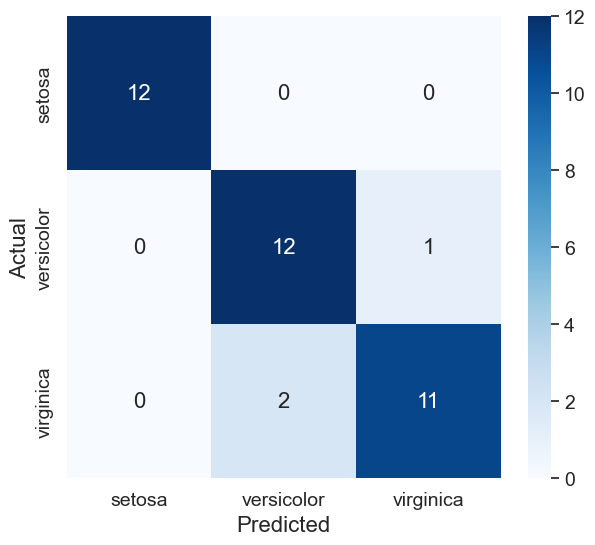

In [5]:
df_cm = pd.DataFrame(mt.confusion_matrix(y_test, y_pred), columns=iris.target_names, index = iris.target_names)
plt.figure(figsize=(7,6))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16});

## Example: Breast cancer

- Consider the breast cancer data set that comes with Orange
- the goal is to predict if a tumor might reappear (recurrence-events) or not (no-recurrence-events)

In [4]:
bc = pd.read_csv("data/breast-cancer.csv")
bc.head()

,recurrence,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [5]:
bc.describe(include='all')      

,recurrence,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
count,286,286,286,286,286,286,286.000000,286,286,286
unique,2,6,3,11,7,3,NaN,2,6,2
top,no-recurrence-events,50-59,premeno,30-34,0-2,no,NaN,left,left_low,no
freq,201,96,150,60,213,222,NaN,152,110,218
mean,NaN,NaN,NaN,NaN,NaN,NaN,2.048951,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.738217,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN


- Categorial data represented by strings cannot be used in ML directly
- Encode the data into a numerical form

In [6]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB, ComplementNB 
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import imblearn.over_sampling as ovs
import sklearn.feature_selection as fs

bc = pd.read_csv("data/breast-cancer.csv")

y = bc.pop("recurrence")
X = bc

le = LabelEncoder()
ohe = OneHotEncoder()
le.fit(y)
ohe.fit(X)

X_train, X_test, y_train, y_test = sel.train_test_split(X, y, test_size=0.25, random_state=123)
X_e = ohe.transform(X_train).toarray()
y_e = le.transform(y_train)


# Perform oversampling: 151 no-recurring (0) cases vs. 63 recurring (1)
print(np.unique(y_e, return_counts=True))
X_e, y_e = ovs.RandomOverSampler(random_state=42).fit_resample(X_e, y_e)
print(np.unique(y_e, return_counts=True))
#mn = MultinomialNB()
mn = GaussianNB()

mn.fit(X_e, y_e)

y_pred = mn.predict(ohe.transform(X_test).toarray())
print(mt.classification_report(le.transform(y_test), y_pred))

(array([0, 1]), array([151,  63]))
(array([0, 1]), array([151, 151]))
              precision    recall  f1-score   support

           0       0.81      0.26      0.39        50
           1       0.34      0.86      0.49        22

    accuracy                           0.44        72
   macro avg       0.58      0.56      0.44        72
weighted avg       0.67      0.44      0.42        72



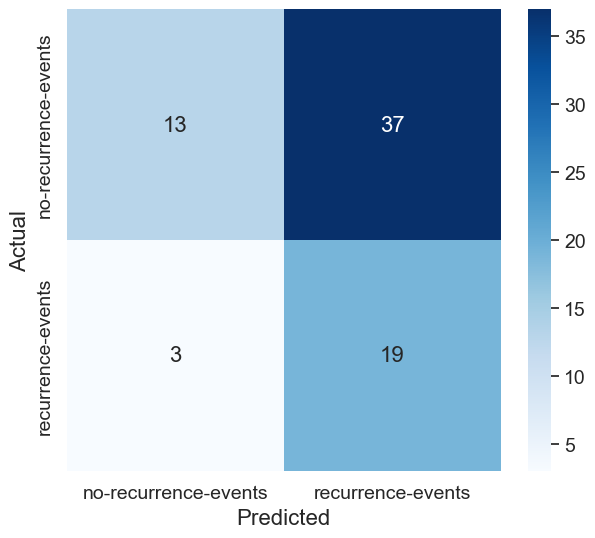

In [7]:
df_cm = pd.DataFrame(mt.confusion_matrix(le.transform(y_test), y_pred), columns=['no-recurrence-events', 'recurrence-events'], 
                     index = ['no-recurrence-events', 'recurrence-events'])
plt.figure(figsize=(7,6))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16});